**Size Chart Generator for Apparel Sellers**

Problem Statement -
Develop an system that generates accurate size charts for apparel sellers with limited or inaccurate size data, based on user body measurements and previous purchase history.

Create a model that:

● Utilizes a database of user body measurements (height, weight, chest, waist, hip, etc.)

● Analyzes users’ previous purchase history and return/exchange data

● Clusters similar body types and their corresponding successful purchases

● Generates a comprehensive size chart for sellers, including measurements for different
sizes (S, M, L, XL, etc.)

● Provides confidence scores for each measurement in the generated size chart.

● Allows for easy updating as new purchase data becomes available

Judging Criteria
1. Accuracy of generated size charts compared to brands with known accurate data
2. Handling of different apparel categories (e.g., tops, bottoms, dresses)
3. Effectiveness in reducing size-related returns (simulated using holdout data)
4. Scalability and adaptability to new brands or product lines
5. Processing speed and efficiency in generating and updating size charts


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/SizeChartGen/BodyMeasurements_Dataset.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print(data.head())

# Display basic information about the dataset
print(data.info())

# Check for missing values
print(data.isnull().sum())


   Gender Height  Weight  Chest Cup Size  Waist  Hips  Body Shape Index Size
0  Female   5'1"      67     37        E     35    38                 4    M
1    Male   6'1"      85     40      NaN     30    31                 3   XL
2    Male   5'3"      77     44      NaN     36    42                 4  XXL
3    Male   6'4"      74     38      NaN     48    49                 4    L
4    Male  4'11"      47     35      NaN     39    41                 0    S
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender            1000 non-null   object
 1   Height            1000 non-null   object
 2   Weight            1000 non-null   int64 
 3   Chest             1000 non-null   int64 
 4   Cup Size          525 non-null    object
 5   Waist             1000 non-null   int64 
 6   Hips              1000 non-null   int64 
 7   Body Shape Ind

In [ ]:
# Convert height from string format "5'1"" to inches
def convert_height_to_inches(height_str):
    if isinstance(height_str, str):
        feet, inches = height_str.split("'")
        inches = inches.replace('"', '').strip()  # Remove the double quotes and spaces
        return int(feet) * 12 + int(inches)
    return height_str

# Apply the conversion function to the 'Height' column
data['Height'] = data['Height'].apply(convert_height_to_inches)

# Handle any missing data (if necessary)
#data = data.dropna()  # Dropping rows with missing values for simplicity

# Convert categorical 'Gender' data to numerical values
#data = pd.get_dummies(data, columns=['Gender'], drop_first=True)

# Display the cleaned dataset
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender            1000 non-null   object
 1   Height            1000 non-null   int64 
 2   Weight            1000 non-null   int64 
 3   Chest             1000 non-null   int64 
 4   Cup Size          525 non-null    object
 5   Waist             1000 non-null   int64 
 6   Hips              1000 non-null   int64 
 7   Body Shape Index  1000 non-null   int64 
 8   Size              1000 non-null   object
dtypes: int64(6), object(3)
memory usage: 70.4+ KB
None


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/drive/MyDrive/SizeChartGen/BodyMeasurements_Dataset.csv'
data = pd.read_csv(file_path)

# Step 1: Data Cleaning

# Optional: Convert non-numeric features if needed
# For example, you could use one-hot encoding
# data = pd.get_dummies(data, columns=non_numeric_features)



# Convert height from string format "5'1"" to inches
def convert_height_to_inches(height_str):
    if isinstance(height_str, str):
        feet, inches = height_str.split("'")
        inches = inches.replace('"', '').strip()  # Remove the double quotes and spaces
        return int(feet) * 12 + int(inches)
    return height_str

# Apply the conversion function to the 'Height' column
data['Height'] = data['Height'].apply(convert_height_to_inches)
# Step 2: Filter numeric features
#numeric_features = data.select_dtypes(include=['number']).columns

# Handle any missing data by dropping rows with missing values
#data = data.dropna()
data['Cup Size'].fillna('M', inplace=True)


# Convert 'Cup Size' to numerical values
cup_size_mapping = { 'M':0, 'AA': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'DD': 6, 'E': 7, 'F': 8}
data['Cup Size'] = data['Cup Size'].map(cup_size_mapping)

# Convert categorical 'Gender' data to numerical values
Gender_mapping = { 'Female':1, 'Male':0};
data['Gender'] = data['Gender'].map(Gender_mapping)
data = pd.get_dummies(data, columns=['Gender'], drop_first=True)
numeric_features = data.select_dtypes(include=['number']).columns

# Step 2: Basic Data Overview
print("Data Head:")
print(data.head())

print("\nData Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# Step 3: Visualizing Distributions
#numeric_features = ['Height', 'Weight', 'Chest', 'Cup Size', 'Waist', 'Hips', 'Body Shape Index', 'Size']

# # Plot distributions of numeric features
# data[numeric_features].hist(bins=15, figsize=(15, 10), layout=(3, 3))
# plt.show()

# # Pairplot to visualize relationships between features
# sns.pairplot(data[numeric_features])
# plt.show()

# Step 4: Correlation Heatmap
#plt.figure(figsize=(10, 8))
#sns.heatmap(data[numeric_features].corr(), annot=True, cmap='coolwarm')
#plt.show()



from sklearn.preprocessing import StandardScaler

# Step 3: Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[numeric_features])

# # Standardize the numerical features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(data[numeric_features])

# # Perform KMeans clustering
# n_clusters = 5  # This can be tuned
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# data['Cluster'] = kmeans.fit_predict(X_scaled)

# # Visualize the clustering
# sns.pairplot(data, hue='Cluster', vars=numeric_features)
# plt.show()


<ipython-input-4-fd13c8cf4324>:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Cup Size'].fillna('M', inplace=True)


Data Head:
   Height  Weight  Chest  Cup Size  Waist  Hips  Body Shape Index Size  \
0      61      67     37         7     35    38                 4    M   
1      73      85     40         0     30    31                 3   XL   
2      63      77     44         0     36    42                 4  XXL   
3      76      74     38         0     48    49                 4    L   
4      59      47     35         0     39    41                 0    S   

   Gender_1  
0      True  
1     False  
2     False  
3     False  
4     False  

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Height            1000 non-null   int64 
 1   Weight            1000 non-null   int64 
 2   Chest             1000 non-null   int64 
 3   Cup Size          1000 non-null   int64 
 4   Waist             1000 non-null   int64 
 5   Hips     

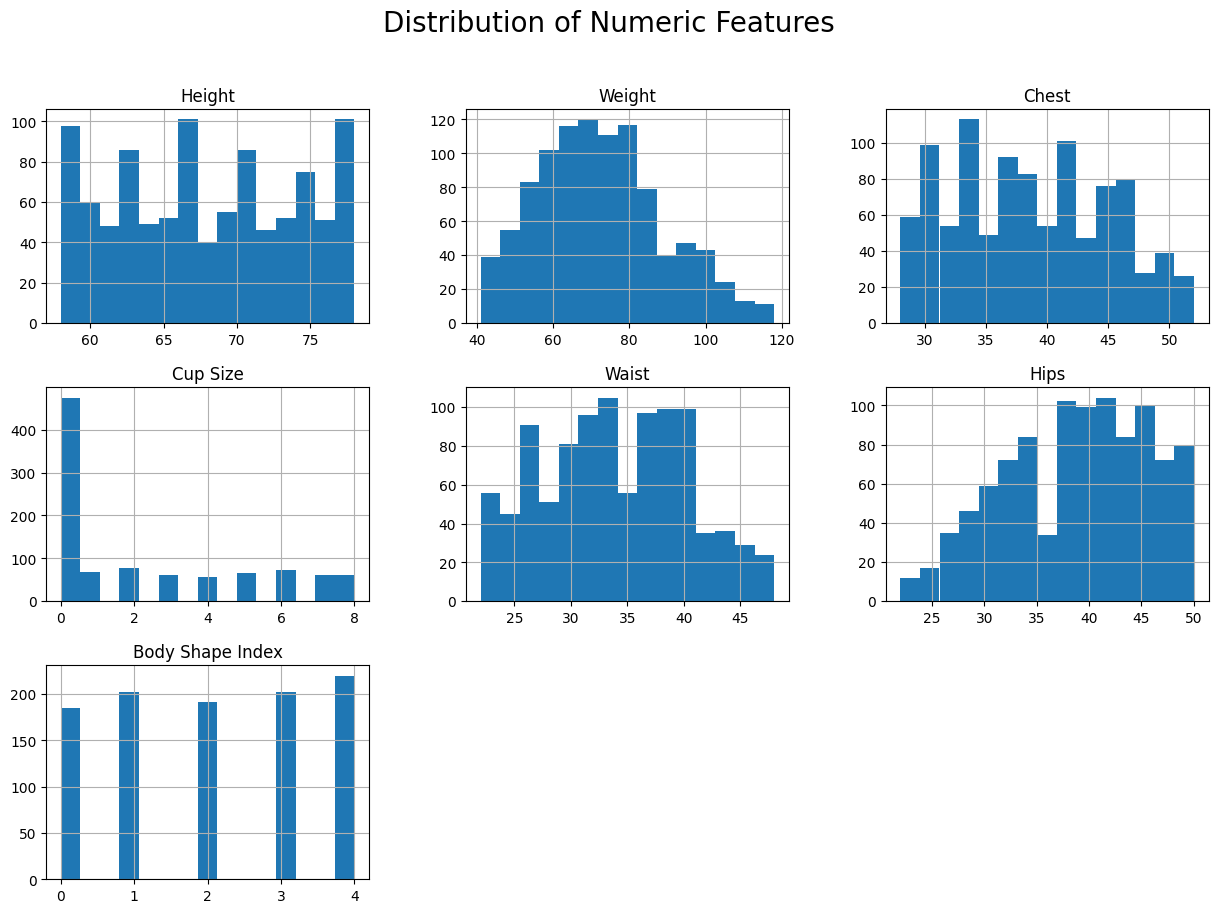

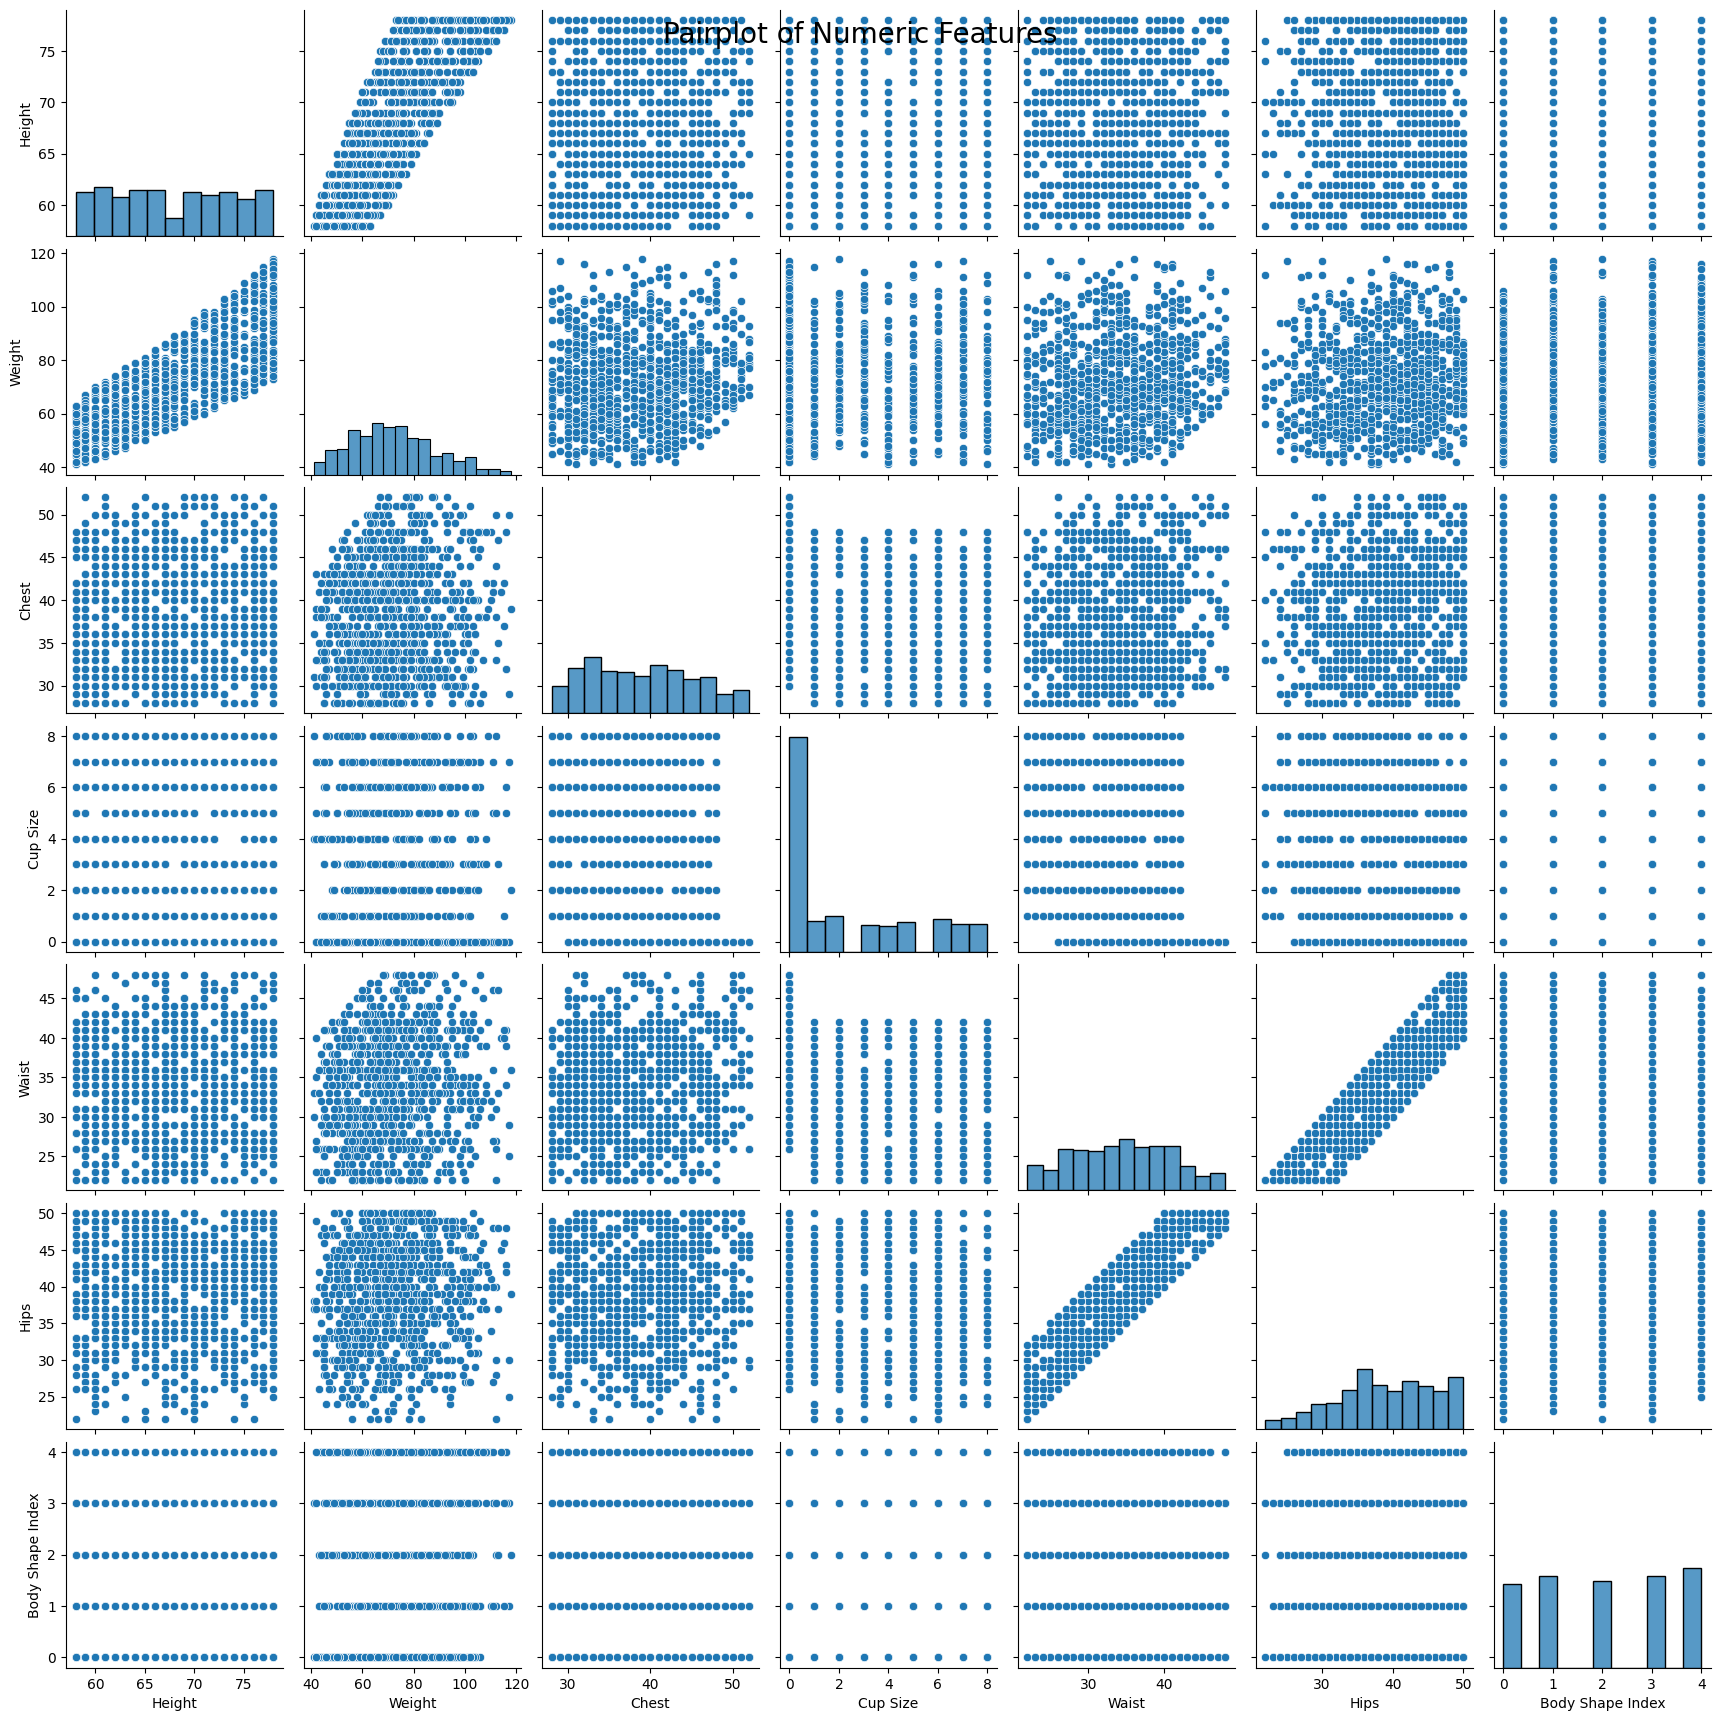

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions of numeric features
data[numeric_features].hist(bins=15, figsize=(15, 10), layout=(3, 3))
plt.suptitle('Distribution of Numeric Features', fontsize=20)
plt.show()

# Pairplot to visualize relationships between features
sns.pairplot(data[numeric_features])
plt.suptitle('Pairplot of Numeric Features', fontsize=20)
plt.show()


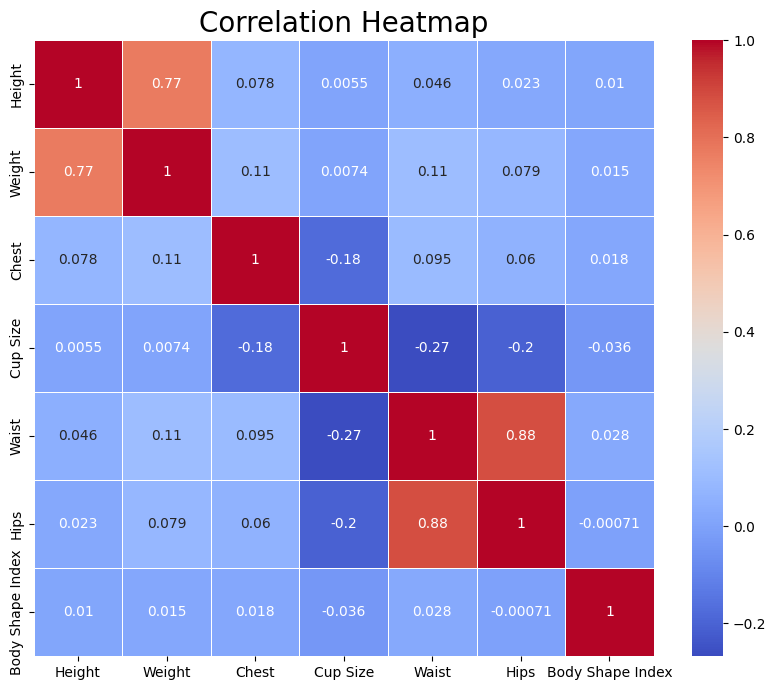

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=20)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming 'Size' is the target variable in your dataset
# First, ensure 'Size' is a column in the dataset
if 'Size' in data.columns:
    # Features
    features = numeric_features.tolist()
    X = data[features]
    y = data['Size']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train a RandomForestClassifier
    model = RandomForestClassifier(n_estimators=15, random_state=30)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)
    print(y_pred)
    print(y_test.values)

    # Evaluate the model
    print(f"Accuracy:, {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(classification_report(y_test, y_pred))
else:
    print("The dataset does not contain a 'Size' column.")


['XS' 'XS' 'XS' 'XS' 'XXL' 'M' 'L' 'XS' 'XS' 'XXL' 'XS' 'XXL' 'S' 'XXL'
 'M' 'XS' 'M' 'M' 'XXL' 'XXL' 'XS' 'S' 'XL' 'XXL' 'XS' 'XS' 'M' 'XS' 'XXL'
 'XS' 'M' 'XS' 'XXL' 'XS' 'S' 'S' 'M' 'XS' 'XS' 'S' 'M' 'XS' 'XS' 'XXL'
 'XXL' 'XS' 'L' 'M' 'XS' 'M' 'XS' 'XS' 'XS' 'L' 'XS' 'XS' 'L' 'XL' 'S'
 'XXL' 'XXL' 'XS' 'XXL' 'XXL' 'XL' 'S' 'S' 'M' 'XXL' 'XXL' 'M' 'S' 'XXL'
 'XS' 'XXL' 'XXL' 'XXL' 'XXL' 'XXL' 'XXL' 'XXL' 'L' 'XL' 'L' 'XXL' 'XS'
 'L' 'M' 'XXL' 'XS' 'L' 'XXL' 'L' 'S' 'XXL' 'S' 'XL' 'XXL' 'L' 'XXL' 'XXL'
 'M' 'XS' 'L' 'L' 'XXL' 'L' 'XXL' 'XS' 'L' 'XS' 'XS' 'XXL' 'XS' 'XS' 'XL'
 'XS' 'S' 'L' 'XS' 'XXL' 'XS' 'XXL' 'XXL' 'XXL' 'XS' 'S' 'L' 'L' 'XS' 'XL'
 'XXL' 'L' 'XL' 'XXL' 'S' 'XXL' 'XXL' 'S' 'XL' 'XXL' 'XL' 'XXL' 'XS' 'XS'
 'XXL' 'XXL' 'XXL' 'XXL' 'XL' 'XXL' 'XL' 'XS' 'XL' 'M' 'XS' 'XL' 'XS'
 'XXL' 'XXL' 'XXL' 'XXL' 'XXL' 'XXL' 'XS' 'M' 'XS' 'XL' 'M' 'XS' 'XL' 'XS'
 'S' 'XXL' 'XL' 'XS' 'XXL' 'XS' 'XL' 'XXL' 'XS' 'XS' 'XXL' 'M' 'L' 'M'
 'XS' 'XXL' 'XS' 'XXL' 'L' 'XS' 'XL' 'XS' 'M' 'XS' 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Assuming your trained RandomForestClassifier is stored as `model` and you have already scaled the data

# Sample input: Prompt the user for their measurements
user_input = {
    'Gender': input("Enter your gender (Male/Female): "),
    'Height': float(input("Enter your height in inches (e.g., 66): ")),
    'Weight': float(input("Enter your weight in pounds (e.g., 150): ")),
    'Chest': float(input("Enter your chest measurement in inches (e.g., 38): ")),
    'Waist': float(input("Enter your waist measurement in inches (e.g., 32): ")),
    'Hips': float(input("Enter your hip measurement in inches (e.g., 40): ")),
    # Optional feature 'Body Shape Index' (only include if it was used during training)
    # 'Body Shape Index': float(input("Enter your Body Shape Index (optional, enter 0 if unknown): "))
}

# Step 1: If the user is female, ask for cup size
if user_input['Gender'].lower() == 'female':
    user_input['Cup Size'] = input("Enter your cup size (AA, A, B, C, D, etc.): ")
else:
    # If the user is male, set cup size to a neutral default (e.g., 0)
    user_input['Cup Size'] = 'M'  # 'M' for neutral or default cup size

# Convert the input dictionary to a DataFrame
user_df = pd.DataFrame([user_input])

# Step 2: Convert Gender to numerical values (e.g., Male: 0, Female: 1)
gender_mapping = {'Male': 0, 'Female': 1}
user_df['Gender'] = user_df['Gender'].map(gender_mapping)

# Step 3: Convert Cup Size to numerical values
cup_size_mapping = {'M': 0, 'AA': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'DD': 6, 'E': 7, 'F': 8}
user_df['Cup Size'] = user_df['Cup Size'].map(cup_size_mapping)

# Step 4: Ensure that only the columns used during training are included
# Example: If 'Body Shape Index' was not used in training, exclude it here
numeric_features = ['Gender', 'Height', 'Weight', 'Chest', 'Cup Size', 'Waist', 'Hips']  # Adjust based on training features

# Step 5: Feature scaling (use the same scaler you used during training)
scaler = StandardScaler()
user_df_scaled = scaler.fit_transform(user_df[numeric_features])

# Step 6: Predict the size using the trained RandomForestClassifier model
predicted_size = model.predict(user_df_scaled)

# Output the predicted size
print(f"The predicted size based on your input is: {predicted_size[0]}")


Enter your gender (Male/Female): Male
Enter your height in inches (e.g., 66): 70
Enter your weight in pounds (e.g., 150): 160
Enter your chest measurement in inches (e.g., 38): 28
Enter your waist measurement in inches (e.g., 32): 32
Enter your hip measurement in inches (e.g., 40): 40
The predicted size based on your input is: XS


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# import numpy as np
# importances = model.feature_importances_
# indices = np.argsort(importances)[::-1]

# plt.figure(figsize=(10, 6))
# plt.title("Feature Importance", fontsize=20)
# plt.bar(range(X.shape[1]), importances[indices], color="r", align="center")
# plt.xticks(range(X.shape[1]), [numeric_features[i] for i in indices], rotation=90)
# plt.xlim([-1, X.shape[1]])
# plt.show()


In [ ]:
# from sklearn.metrics import confusion_matrix

# # Confusion Matrix
# conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)

# plt.figure(figsize=(10, 7))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
# plt.title('Confusion Matrix', fontsize=20)
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.show()

# # Classification Report Bar Plot
# report = classification_report(y_test, y_pred, output_dict=True)
# report_df = pd.DataFrame(report).transpose()
# report_df = report_df[:-3]  # Exclude support, accuracy, etc.

# report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
# plt.title('Precision, Recall, and F1-Score by Class', fontsize=20)
# plt.xticks(rotation=45)
# plt.show()


In [ ]:
# from sklearn.metrics import roc_curve, auc

# # Calculate the ROC curve and AUC for each class
# fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1], pos_label='Positive_Class_Label')
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(10, 7))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
# plt.legend(loc="lower right")
# plt.show()
